# 00 — Data Preparation & Panel Structure

**This notebook exists because the single most important bug in the original project was never noticed: the data is not one 3,051-week time series.**

It is **panel data** — 27 divisions, each observed weekly for 113 weeks (2018-01-06 to 2020-02-29). Every previous notebook (`Fridgelasso.ipynb`, `lightMGBM.ipynb`, `XGboost.ipynb`, the LightweightMMM notebooks) loaded the flat CSV and either sorted it by `calendar_week` alone (interleaving all 27 divisions on every date) or used the raw row order (which is grouped by division, so a "time-based" 80/20 split was actually splitting *divisions*, not time). Either way, adstock and lag features were computed across division boundaries, which is meaningless — division B's spend has no carryover effect on division T's sales.

This notebook:
1. Loads the raw and cleaned data and shows the panel structure.
2. Finds and fixes a real data quality bug: division "Z" contains 226 rows instead of ~113 — it is actually **two different divisions sharing one label**.
3. Explores why between-division scale differences (up to ~20x) matter enormously for modeling and evaluation choices made in the later notebooks.
4. Defines the **shared train/test split** (last 10 of 113 weeks held out) used identically by every model in this project.

All reusable logic (loading, the Z-fix, adstock, Hill saturation, the holdout split) lives in `../mmm/data.py` and is imported — not copy-pasted — by every notebook that follows.

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mmm import data as D

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (10, 4)


## 1. Raw data: the panel structure

In [2]:
raw = pd.read_csv("../data/raw/sample_media_spend_data.csv")
print(raw.shape)
raw.head(3)


(3051, 10)


,Division,Calendar_Week,Paid_Views,Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Overall_Views,Sales
0,A,01/06/2018,392,422,408,349895.0107,73580,12072,682,59417
1,A,1/13/2018,787,904,110,506270.2176,11804,9499,853,56806
2,A,1/20/2018,81,970,742,430042.1538,52232,17048,759,48715


In [3]:
counts = raw["Division"].value_counts().sort_index()
print(counts)
print()
print("Every division has 113 rows except:", counts[counts != 113].to_dict())


Division
A    113
B    113
C    113
D    113
E    113
F    113
G    113
H    113
I    113
J    113
K    113
L    113
M    113
N    113
O    113
P    113
Q    113
R    113
S    113
T    113
U    113
V    113
W    113
X    113
Y    113
Z    226
Name: count, dtype: int64

Every division has 113 rows except: {'Z': 226}


## 2. The "Z" bug

Division "Z" has 226 rows — exactly double every other division. Splitting it into its two 113-row blocks (the file is grouped division-then-week, so the blocks are contiguous, not interleaved) shows they share the *same 113 calendar weeks* but have *different spend and sales values*: two distinct divisions were mislabeled with the same code somewhere upstream of this file. `mmm.data.fix_z_division` splits them into `Z1`/`Z2` so no division mixes two unrelated stores' worth of spend and sales into one adstock sequence.

In [4]:
z = raw[raw["Division"] == "Z"].reset_index(drop=True)
b1, b2 = z.iloc[:113], z.iloc[113:].reset_index(drop=True)
print("Same 113 weeks in both blocks:", (b1["Calendar_Week"].values == b2["Calendar_Week"].values).all())
print("Block 1 mean sales: {:,.0f}   Block 2 mean sales: {:,.0f}".format(b1["Sales"].mean(), b2["Sales"].mean()))


Same 113 weeks in both blocks: True
Block 1 mean sales: 191,006   Block 2 mean sales: 108,261


In [5]:
df = D.load_panel()
print(f"Panel after cleaning: {df['division'].nunique()} divisions x {df['calendar_week'].nunique()} weeks = {len(df)} rows")
assert df['division'].nunique() == 27
sorted(df['division'].unique())


Panel after cleaning: 27 divisions x 113 weeks = 3051 rows


['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z1',
 'Z2']

## 3. Why the between-division scale gap matters

Divisions differ in average weekly sales by roughly **20x** (smallest ~$38K/week, largest ~$876K/week). This one fact drives several methodology decisions made throughout the rest of the project:

- Every linear model needs **division fixed effects** (dummies) or it will badly under/over-predict large vs. small divisions.
- The **target is heavily right-skewed** (skew ≈ 5.6) almost entirely because of this between-division spread; `log1p(sales)` (skew ≈ 0.66) is a much better-behaved regression target and is used throughout.
- **Pooled R² across the whole panel is a misleading headline number** — a model that does nothing more than learn "which division is this" already explains ~88% of variance, because between-division variance dwarfs week-to-week variance within a division. Section 5 below makes this concrete; every model-comparison notebook keeps this naive baseline front and center for exactly this reason.

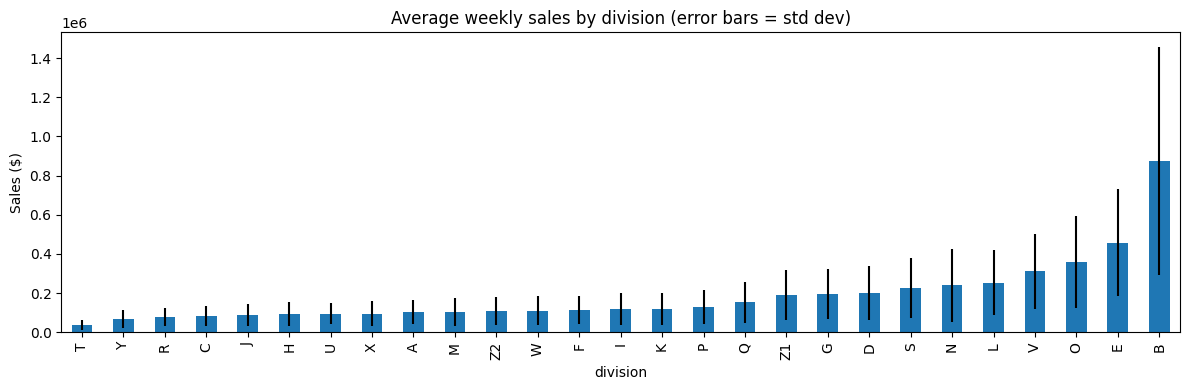

Scale ratio (largest/smallest division mean): 22.9x


In [6]:
div_stats = df.groupby("division")["sales"].agg(["mean", "std"]).sort_values("mean")
div_stats.plot(kind="bar", y="mean", yerr="std", legend=False, figsize=(12, 4),
                title="Average weekly sales by division (error bars = std dev)")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.savefig("../reports/figures/00_division_scale.png", dpi=110)
plt.show()
print(f"Scale ratio (largest/smallest division mean): {div_stats['mean'].max() / div_stats['mean'].min():.1f}x")


In [7]:
print("Skew of raw sales:      ", round(df["sales"].skew(), 2))
print("Skew of log1p(sales):   ", round(np.log1p(df["sales"]).skew(), 2))


Skew of raw sales:       5.62
Skew of log1p(sales):    0.66


## 4. A second seasonal fact that shapes every model: the holiday spike

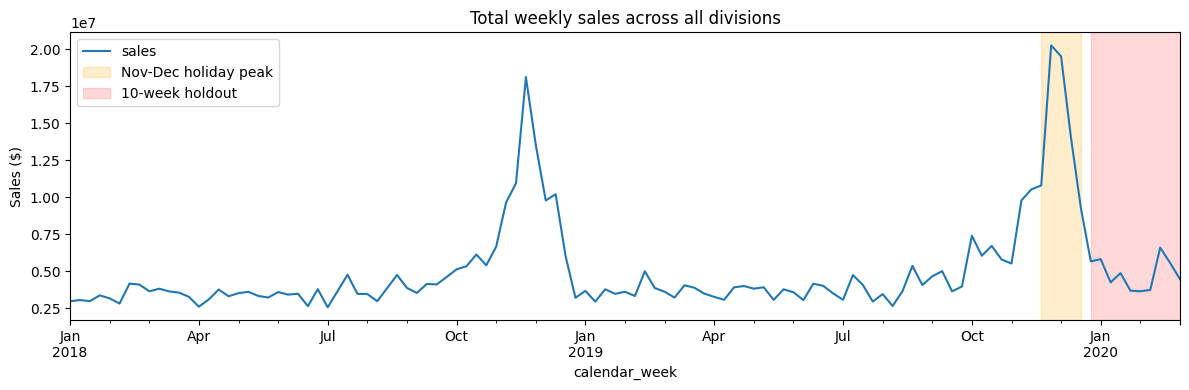

In [8]:
weekly_total = df.groupby("calendar_week")["sales"].sum()
weekly_total.plot(title="Total weekly sales across all divisions", figsize=(12, 4))
plt.ylabel("Sales ($)")
plt.axvspan(pd.Timestamp("2019-11-23"), pd.Timestamp("2019-12-21"), color="orange", alpha=0.2, label="Nov-Dec holiday peak")
plt.axvspan(pd.Timestamp("2019-12-28"), pd.Timestamp("2020-02-29"), color="red", alpha=0.15, label="10-week holdout")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/00_weekly_seasonality.png", dpi=110)
plt.show()


Total sales jump roughly **4x** in the Nov 30 / Dec 7 weeks (Black Friday / holiday season) and then crash to a trough that lasts through February. With only ~2.2 years of history, this shape is seen only twice. That single fact turns out to matter a lot for model evaluation (see `05_model_comparison_and_insights.ipynb`): a low-order Fourier seasonality term is too smooth to capture a spike this sharp, and whichever exact weeks land in a holdout window (a calm trough vs. a week that includes the spike) can flip which model looks best.

## 5. The shared time-based holdout

In [9]:
train_weeks, test_weeks = D.time_split_weeks(df)
print(f"Train: {len(train_weeks)} weeks ({pd.Timestamp(train_weeks[0]).date()} to {pd.Timestamp(train_weeks[-1]).date()})")
print(f"Test:  {len(test_weeks)} weeks ({pd.Timestamp(test_weeks[0]).date()} to {pd.Timestamp(test_weeks[-1]).date()})")
print()
print("This split is identical across every notebook in this project -- no model is ever")
print("trained on a row whose calendar_week falls in the test set.")


Train: 103 weeks (2018-01-06 to 2019-12-21)
Test:  10 weeks (2019-12-28 to 2020-02-29)

This split is identical across every notebook in this project -- no model is ever
trained on a row whose calendar_week falls in the test set.


## 6. The naive baseline every model must beat

Before touching a single media coefficient: what does a model get "for free" just by knowing which division a row belongs to? This is the honest baseline for the whole project (see `mmm/eval.py`), and it is **surprisingly strong** on this holdout — a full discussion is in `05_model_comparison_and_insights.ipynb`.

In [10]:
from mmm.eval import metrics
tr_mask = df["calendar_week"].isin(train_weeks)
te_mask = df["calendar_week"].isin(test_weeks)
train_div_mean = df.loc[tr_mask].groupby("division")["sales"].mean()
naive_pred = df.loc[te_mask, "division"].map(train_div_mean).values
print("Naive baseline (predict each division's own training-period mean):")
print(metrics(df.loc[te_mask, "sales"], naive_pred))


Naive baseline (predict each division's own training-period mean):
{'R2': 0.8848676494955905, 'RMSE': 57232.36000158885, 'MAPE': 0.21864049160744037}
